In [2]:
#imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table   
from astropy.coordinates import SkyCoord     
from astropy import units as u                   
from astropy.cosmology import Planck18 as cosmo
from astropy.table import unique
from astropy.visualization import make_lupton_rgb

In [3]:
#read in the catalog
path_to_catalog = '/fs/ess/PCON0003/desi-visualizations/catalogs/zall-tilecumulative-fuji.fits'  
catalog = Table.read(path_to_catalog)

print('Total number of objects:', len(catalog))

Total number of objects: 3611000


In [4]:
# Filter out entries with ZWARN != 0
if 'ZWARN' in catalog.colnames:
    catalog = catalog[catalog['ZWARN'] == 0]

#Filter out high ZERR values
if 'ZERR' in catalog.colnames:
    catalog = catalog[catalog['ZERR'] < 0.001]


#Filter out duplicates
catalog = unique(catalog, keys=['TARGET_RA', 'TARGET_DEC'])
print('Objects kept:', len(catalog))

Objects kept: 1653034


In [5]:
# trim catalog
RA_max = 360   # RA ranges from 0-360
DEC_max = 90   # DEC ranges from -90 to 90 
catalog = catalog[(catalog['TARGET_RA'] < RA_max) & (catalog['TARGET_DEC'] < DEC_max)]

# limit redshift
z_min = 0.01 # below this, they're mostly stars or errors.
z_max = 3    # DESI goes higher than this, but it is sparse and harder to visualize.
catalog = catalog[(catalog['Z'] > z_min) & (catalog['Z'] < z_max)]

# remove galaxies with unrealisting imaging fluxes
flux_g_max = 50  # these are quite faint. You calso can't have negative flux!
flux_g_min = 0
flux_r_max = 50  
flux_r_min = 0
flux_z_max = 50  
flux_z_min = 0
flux_W1_max = 50  
flux_W1_min = 0
flux_W2_max = 50  
flux_W2_min = 0
catalog = catalog[(catalog['FLUX_G'] < flux_g_max) & (catalog['FLUX_G'] > flux_g_min) & (catalog['FLUX_R'] < flux_r_max) & (catalog['FLUX_R'] > flux_r_min) & (catalog['FLUX_Z'] < flux_z_max) & (catalog['FLUX_Z'] > flux_z_min) & (catalog['FLUX_W1'] < flux_W1_max) & (catalog['FLUX_W1'] > flux_W1_min) & (catalog['FLUX_W2'] < flux_W2_max) & (catalog['FLUX_W2'] > flux_W2_min)]

In [6]:
comoving_distance = cosmo.comoving_distance(catalog['Z'])  # calculate the comoving distance to each object based on its redshift and the cosmology (to know: what is comoving distance?)
coords = SkyCoord(ra=catalog['TARGET_RA']*u.degree, dec=catalog['TARGET_DEC']*u.degree, distance=comoving_distance)  # astropy converts this into a 3D coordinate system

In [7]:
#define 3d coords
x = coords.cartesian.x  # these are still astropy objects, i.e. they have assigned units (Mpc)
y = coords.cartesian.y
z = coords.cartesian.z

In [8]:
#define redshift and fluxes
redshift = catalog['Z'] 
flux_g = catalog['FLUX_G']
flux_r = catalog['FLUX_R']
flux_z = catalog['FLUX_Z']
flux_w1 = catalog['FLUX_W1']
flux_w2 = catalog['FLUX_W2']
#xtra
object_type = catalog['SPECTYPE']
zerr = catalog['ZERR']
zwarn = catalog['ZWARN']

In [9]:
#define apparent magnitudes
app_mag_G = -2.5*np.log10(catalog['FLUX_G'])+22.5 
app_mag_R = -2.5*np.log10(catalog['FLUX_R'])+22.5 
app_mag_Z = -2.5*np.log10(catalog['FLUX_Z'])+22.5 
app_mag_W1 = -2.5*np.log10(catalog['FLUX_W1'])+22.5
app_mag_W2 = -2.5*np.log10(catalog['FLUX_W2'])+22.5


In [10]:
#define absolute magnitudes
def apparent_to_absolute_magnitude(m, z):
    d_L = cosmo.luminosity_distance(z)  
    M = m - 5 * np.log10(d_L.to(u.pc).value) + 5  
    return M
abs_mag_g = apparent_to_absolute_magnitude(app_mag_G, redshift)
abs_mag_r = apparent_to_absolute_magnitude(app_mag_R, redshift)
abs_mag_z = apparent_to_absolute_magnitude(app_mag_Z, redshift)
abs_mag_w1 = apparent_to_absolute_magnitude(app_mag_W1, redshift)
abs_mag_w2 = apparent_to_absolute_magnitude(app_mag_W2, redshift)


Reddening Trend Found!
Equation: Color = (0.9108 * Z) + 0.6706


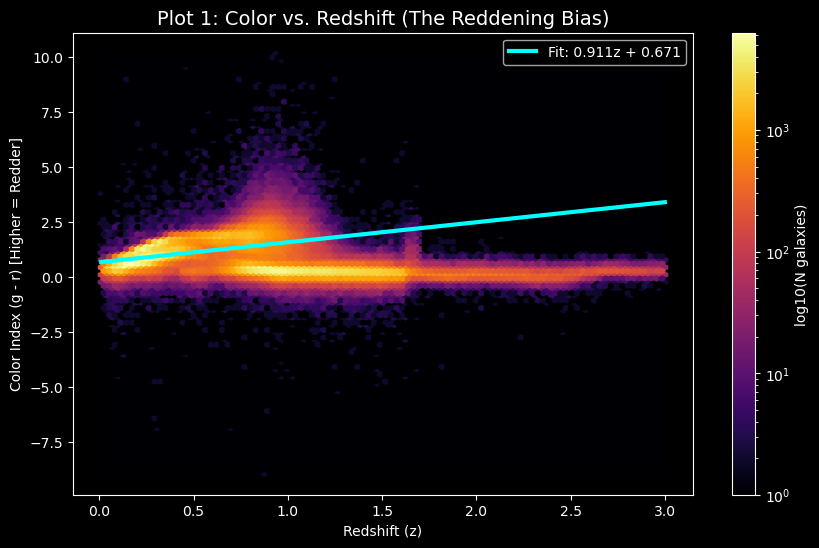

In [ ]:
# Calculate the uncorrected color index (g - r)
color_g_r = abs_mag_g - abs_mag_r

z_vals = catalog['Z']
color_vals = color_g_r

# Create a mask to isolate the normal galaxies for the math (ignoring high-z quasars)
math_mask = z_vals < 0.8
z_math = z_vals[math_mask]
color_math = color_vals[math_mask]

# Fit the line using ONLY the masked galaxy data
slope, intercept = np.polyfit(z_math, color_math, 1)


print(f"Reddening Trend Found")
print(f"Equation: Color = ({slope:.4f} * Z) + {intercept:.4f}")

# Create Plot 1
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Use hexbin for massive datasets (creates a density heatmap)
plt.hexbin(z_vals, color_vals, gridsize=100, cmap='inferno', bins='log')
cb = plt.colorbar()
cb.set_label('log10(N galaxies)')

# Generate the line of best fit to draw on top
z_line = np.linspace(z_vals.min(), z_vals.max(), 100)
color_line = (slope * z_line) + intercept

# Plot the trend line in bright cyan so it stands out against the heatmap
plt.plot(z_line, color_line, color='cyan', linewidth=3, label=f'Fit: {slope:.3f}z + {intercept:.3f}')

plt.title("Plot 1: Color vs. Redshift (The Reddening Bias)", fontsize=14)
plt.xlabel("Redshift (z)")
plt.ylabel("Color Index (g - r) [Higher = Redder]")
plt.legend()
plt.show()

# Reset the style back to default
plt.style.use('default')

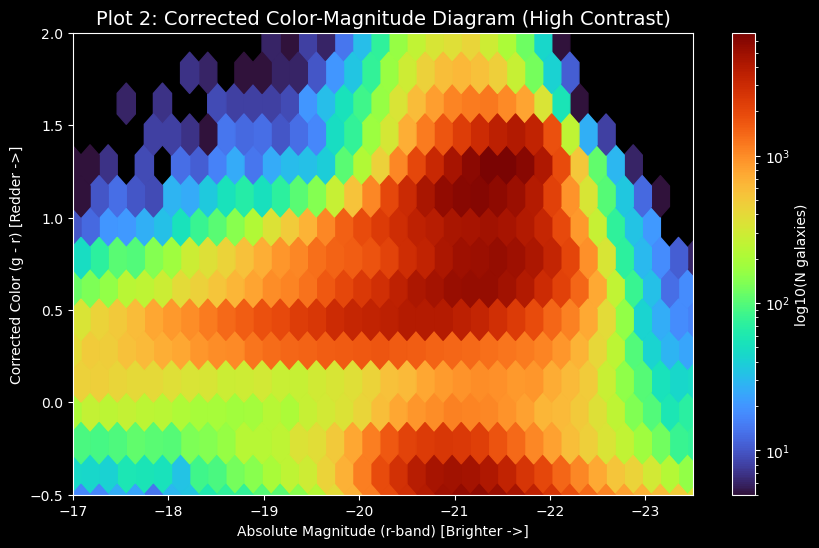

In [ ]:
# Apply the empirical correction!
# We subtract the bias (slope * Z) from the original colors to 'flatten' the universe
catalog['corrected_color'] = color_g_r - (slope * catalog['Z'])

# Extract Absolute Magnitude for the X-axis (r-band is the standard baseline)
mag_vals = abs_mag_r 
corrected_color_vals = catalog['corrected_color']

# Create Plot 2: The Color-Magnitude Diagram (CMD)
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# THE FIXES:
# - mincnt=5: Hides any hexagon with less than 5 galaxies. Clears the "fog"
# - cmap='turbo': A high-contrast rainbow map perfect for showing density peaks.
# - gridsize=100: Slightly larger hexes to smooth out the clusters.
plt.hexbin(mag_vals, corrected_color_vals, gridsize=100, cmap='turbo', bins='log', mincnt=5)
cb = plt.colorbar()
cb.set_label('log10(N galaxies)')

# Invert X-axis
plt.gca().invert_xaxis()

# Zoom in slightly tighter on the Y-axis to frame the split
plt.xlim(-17, -23.5)
plt.ylim(-0.5, 2.0)

plt.title("Plot 2: Corrected Color-Magnitude Diagram (High Contrast)", fontsize=14)
plt.xlabel("Absolute Magnitude (r-band) [Brighter ->]")
plt.ylabel("Corrected Color (g - r) [Redder ->]")

plt.show()

# Reset the style
plt.style.use('default')

In [ ]:
# Convert absolute magnitudes back to intrinsic linear luminosities
#lum_r = 10 ** (-0.4 * abs_mag_r)
#lum_g = 10 ** (-0.4 * abs_mag_g)

# Normalize the numbers so the Lupton algorithm doesn't freak out over giant scientific values
#norm = np.median(lum_r)
#lum_r = lum_r / norm
#lum_g = lum_g / norm

# Map to RGB
# R = r-band (reddish), B = g-band (blue/greenish)
# We don't have a true deep-blue u-band in the CSV, so we synthesize Green by mixing r and g
#rest_R = lum_r
#rest_G = (lum_r + lum_g) / 2.0
#rest_B = lum_g

# Run the Lupton algorithm
#print("Calculating Rest-Frame RGB...")
# Stretch is slightly higher here because our normalized data centers around 1
#rest_rgb_array = make_lupton_rgb(rest_R, rest_G, rest_B, stretch=2.0, Q=10)

# Unpack and overwrite our color columns
#r_arr, g_arr, b_arr = rest_rgb_array.T

#catalog['color_r'] = r_arr / 255.0
#catalog['color_g'] = g_arr / 255.0
#catalog['color_b'] = b_arr / 255.0

#print("RGB colors generated!")

In [ ]:
# Convert absolute magnitudes back to intrinsic linear luminosities
lum_r = 10 ** (-0.4 * abs_mag_r)
lum_g = 10 ** (-0.4 * abs_mag_g)

# Normalize the numbers so the Lupton algorithm doesn't freak out over giant scientific values
norm = np.percentile(lum_r, 5)
lum_r = lum_r / norm
lum_g = lum_g / norm

# Map to RGB with a Blue Boost
rest_R = lum_r
rest_G = (lum_r + lum_g) / 2.0
# Multiply the blue channel by 1.5 to artificially boost the young star-forming regions
rest_B = lum_g * 1.5 

# Run the Lupton algorithm
print("Calculating Boosted RGB...")
# Lower stretch = brighter overall. Lower Q = deeply saturated colors
rest_rgb_array = make_lupton_rgb(rest_R, rest_G, rest_B, stretch=0.2, Q=2)

# 4. Unpack and overwrite our color columns
r_arr, g_arr, b_arr = rest_rgb_array.T

catalog['color_r'] = r_arr / 255.0
catalog['color_g'] = g_arr / 255.0
catalog['color_b'] = b_arr / 255.0

print("Boosted colors generated.")

Calculating Boosted RGB...
Boosted colors generated!


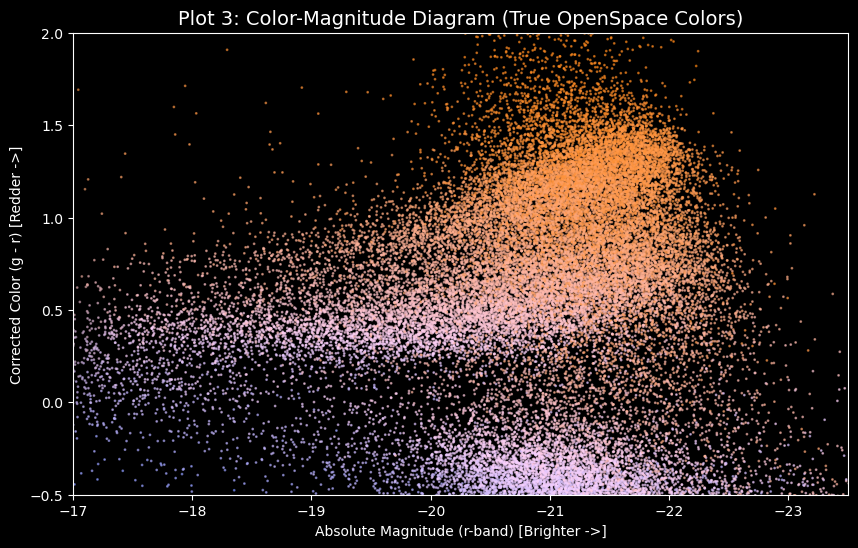

In [ ]:
# Take a random sample to prevent the "inkblot" overplotting effect
sample_size = 50000
sample_size = min(sample_size, len(catalog)) # Safety check just in case

# Generate random indices and extract the sample
rng = np.random.default_rng()
sample_indices = rng.choice(len(catalog), size=sample_size, replace=False)
sampled_catalog = catalog[sample_indices]

# Extract X and Y values from the sample
# Since abs_mag_r is a standalone variable, we apply the sample indices to it directly
mag_vals_sample = abs_mag_r[sample_indices] 
corrected_color_sample = sampled_catalog['corrected_color']

# Format the Boosted RGB colors we made earlier for Matplotlib
# Bypassing the catalog and slicing the standalone color arrays directly.
# We divide by 255.0 here to convert them into the 0.0-1.0 format Matplotlib needs
colors = np.column_stack((
    np.clip(r_arr[sample_indices] / 255.0, 0, 1), 
    np.clip(g_arr[sample_indices] / 255.0, 0, 1), 
    np.clip(b_arr[sample_indices] / 255.0, 0, 1)
))

# Create Plot 3
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Scatter plot: 'c' applies our custom colors, 's' makes dots tiny, 'alpha' makes them transparent
plt.scatter(mag_vals_sample, corrected_color_sample, c=colors, s=1, alpha=0.6)

# Invert X-axis and match the exact zoom/crop from Plot 2
plt.gca().invert_xaxis()
plt.xlim(-17, -23.5)
plt.ylim(-0.5, 2.0)

plt.title("Plot 3: Color-Magnitude Diagram (True OpenSpace Colors)", fontsize=14)
plt.xlabel("Absolute Magnitude (r-band) [Brighter ->]")
plt.ylabel("Corrected Color (g - r) [Redder ->]")

plt.show()

# Reset the style back to default
plt.style.use('default')

In [20]:
print(catalog.colnames)

['TARGETID', 'SURVEY', 'PROGRAM', 'LASTNIGHT', 'SPGRPVAL', 'Z', 'ZERR', 'ZWARN', 'CHI2', 'COEFF', 'NPIXELS', 'SPECTYPE', 'SUBTYPE', 'NCOEFF', 'DELTACHI2', 'PETAL_LOC', 'DEVICE_LOC', 'LOCATION', 'FIBER', 'COADD_FIBERSTATUS', 'TARGET_RA', 'TARGET_DEC', 'PMRA', 'PMDEC', 'REF_EPOCH', 'LAMBDA_REF', 'FA_TARGET', 'FA_TYPE', 'OBJTYPE', 'FIBERASSIGN_X', 'FIBERASSIGN_Y', 'PRIORITY', 'SUBPRIORITY', 'OBSCONDITIONS', 'RELEASE', 'BRICKNAME', 'BRICKID', 'BRICK_OBJID', 'MORPHTYPE', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'FLUX_IVAR_W1', 'FLUX_IVAR_W2', 'FIBERFLUX_G', 'FIBERFLUX_R', 'FIBERFLUX_Z', 'FIBERTOTFLUX_G', 'FIBERTOTFLUX_R', 'FIBERTOTFLUX_Z', 'MASKBITS', 'SERSIC', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'REF_ID', 'REF_CAT', 'GAIA_PHOT_G_MEAN_MAG', 'GAIA_PHOT_BP_MEAN_MAG', 'GAIA_PHOT_RP_MEAN_MAG', 'PARALLAX', 'PHOTSYS', 'PRIORITY_INIT', 'NUMOBS_INIT', 'CMX_TARGET', 'DESI_TARGET', 'BGS_TARGET', 'MWS_TARGET', 'SCND_TARGET', 'SV1_DESI_TARGE

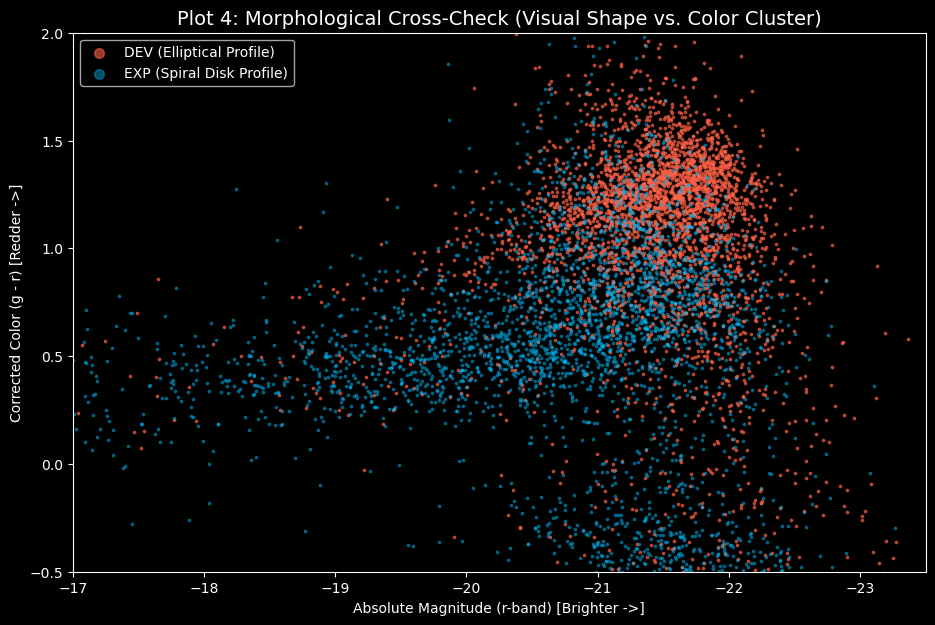

In [ ]:
# Take a clean random sample to prevent overplotting inkblots
sample_size = 30000
sample_size = min(sample_size, len(catalog))

rng = np.random.default_rng()
sample_indices = rng.choice(len(catalog), size=sample_size, replace=False)
sampled_catalog = catalog[sample_indices]

# Extract coordinates using working arrays
mag_vals_sample = abs_mag_r[sample_indices]
corrected_color_sample = sampled_catalog['corrected_color']

# Extract MORPHTYPE and cast to string to prevent byte-string matching bugs (b'DEV' vs 'DEV')
morph_sample = sampled_catalog['MORPHTYPE'].astype(str)

# Setup the plot
plt.style.use('dark_background')
plt.figure(figsize=(11, 7))

# Scatter plot each structural profile type
# DEV = Elliptical (Warm Red)
dev_mask = (morph_sample == 'DEV')
plt.scatter(mag_vals_sample[dev_mask], corrected_color_sample[dev_mask], 
            color='tomato', s=3, alpha=0.6, label='DEV (Elliptical Profile)')

# EXP = Spiral (Bright Blue)
exp_mask = (morph_sample == 'EXP')
plt.scatter(mag_vals_sample[exp_mask], corrected_color_sample[exp_mask], 
            color='deepskyblue', s=3, alpha=0.4, label='EXP (Spiral Disk Profile)')

# Format and bound the plot to match Plot 2 and Plot 3 perfectly
plt.gca().invert_xaxis()
plt.xlim(-17, -23.5)
plt.ylim(-0.5, 2.0)

plt.title("Plot 4: Morphological Cross-Check (Visual Shape vs. Color Cluster)", fontsize=14)
plt.xlabel("Absolute Magnitude (r-band) [Brighter ->]")
plt.ylabel("Corrected Color (g - r) [Redder ->]")
plt.legend(loc='upper left', markerscale=4)

plt.show()
plt.style.use('default')

In [ ]:
# Define the structural rules based on Plot 4 validation
# Condition 1: If it's a Quasar (SPECTYPE == 'QSO') -> Tag as 3
# Condition 2: If it's blue (corrected_color < 0.5) -> Tag as 1 (Spiral)
# Condition 3: If it's red (corrected_color >= 0.5) -> Tag as 2 (Elliptical)
conditions = [
    (catalog['SPECTYPE'] == 'QSO'),
    (catalog['corrected_color'] < 0.5),
    (catalog['corrected_color'] >= 0.5)
]
choices = [3, 1, 2]

# Apply the choices globally to the catalog
catalog['object_subtype'] = np.select(conditions, choices, default=1)

print("--- Pipeline Subtype Summary ---")
print(f"Spirals mapped (ID: 1):      {np.sum(catalog['object_subtype'] == 1)}")
print(f"Ellipticals mapped (ID: 2):  {np.sum(catalog['object_subtype'] == 2)}")
print(f"Quasars mapped (ID: 3):      {np.sum(catalog['object_subtype'] == 3)}")
print("--------------------------------\n")

# Assemble the master table
# Added 'corrected_color' and 'object_subtype' to the very end of the lists
table = Table(
    [
        x, y, z, redshift, zerr, zwarn, object_type, 
        flux_g, flux_r, flux_z, flux_w1, flux_w2, 
        app_mag_G, app_mag_R, app_mag_Z, app_mag_W1, app_mag_W2, 
        abs_mag_g, abs_mag_r, abs_mag_z, abs_mag_w1, abs_mag_w2, 
        catalog['color_r'], catalog['color_g'], catalog['color_b'],
        catalog['corrected_color'], catalog['object_subtype']
    ], 
    names=[
        'x', 'y', 'z', 'redshift', 'zerr', 'zwarn', 'object_type', 
        'flux_g', 'flux_r', 'flux_z', 'flux_w1', 'flux_w2', 
        'app_mag_G', 'app_mag_R', 'app_mag_Z', 'app_mag_W1', 'app_mag_W2', 
        'abs_mag_g', 'abs_mag_r', 'abs_mag_z', 'abs_mag_w1', 'abs_mag_w2', 
        'color_r', 'color_g', 'color_b',
        'corrected_color', 'object_subtype'
    ]
)

# Clean up any weird 2D array dimensions from telescope formatting
for col in table.colnames:
    if len(table[col].shape) > 1:
        table[col] = np.squeeze(table[col])

# 4. Write the final production file
table.write('openspace_assets/desi_catalog_boosted.csv', format='csv', overwrite=True)
print("SUCCESS: Master CSV saved with corrected colors and galaxy subtypes!")

--- Pipeline Subtype Summary ---
Spirals mapped (ID: 1):      418178
Ellipticals mapped (ID: 2):  310526
Quasars mapped (ID: 3):      69555
--------------------------------

SUCCESS: Master CSV saved with corrected colors and galaxy subtypes!


In [ ]:
# Load the exported CSV back into memory
print("Loading exported file from hard drive...")
test_table = Table.read('openspace_assets/desi_catalog_boosted.csv', format='csv')

# Run the 4-Point Safety Inspection
print("\n=== RUNNING PRODUCTION FILE INSPECTION ===")

# Test 1: Data Completeness
print(f"✅ Total rows successfully written: {len(test_table)}")

# Test 2: Column Verification
required_columns = ['corrected_color', 'object_subtype', 'color_r', 'color_g', 'color_b']
missing = [col for col in required_columns if col not in test_table.colnames]
if not missing:
    print("✅ All custom OpenSpace columns are physically present in the file!")
else:
    print(f"❌ WARNING: Missing columns: {missing}")

# Test 3: Subtype Distribution
subtypes, counts = np.unique(test_table['object_subtype'], return_counts=True)
print("\n--- Value Counts for the Lua Script ---")
for st, cnt in zip(subtypes, counts):
    label = {1: "Spirals", 2: "Ellipticals", 3: "Quasars"}.get(st, "Unknown")
    print(f"  Subtype {st} ({label}): {cnt} objects")

# Test 4: Quick Visual Check of the Data Matrix
print("\n=== SNEAK PEEK OF FIRST 3 ROWS ===")
print(test_table['x', 'y', 'z', 'corrected_color', 'object_subtype'][:3])
print("==========================================")

Loading exported file from hard drive...

=== RUNNING PRODUCTION FILE INSPECTION ===
✅ Total rows successfully written: 798259
✅ All custom OpenSpace columns are physically present in the file!

--- Value Counts for the Lua Script ---
  Subtype 1 (Spirals): 418178 objects
  Subtype 2 (Ellipticals): 310526 objects
  Subtype 3 (Quasars): 69555 objects

=== SNEAK PEEK OF FIRST 3 ROWS ===
        x                 y          ...  corrected_color   object_subtype
----------------- ------------------ ... ------------------ --------------
1730.062559502568  73.92517236332625 ... 1.5733920700916944              2
 654.452605183442  28.04805052244264 ... 0.4421001136831082              1
945.1176893777575 40.622510064145146 ...  0.489740408957488              1
